In [1]:
from pythtb import TBModel, WFArray, Mesh, Lattice
import numpy as np
import matplotlib.pyplot as plt

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
number of orbitals          = 2
number of spin components   = 1
number of electronic states = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
No symmetry operations registered.

----------------------------------------
Site energies:
  # 0 ===> -0.400 
  # 1 ===>  0.400 
Hoppings:
  < 0 | H | 1 + [ 0.0 ,  0.0 ] >  ===> -1.0000
  < 1 | H | 0 + [ 1.0 ,  0.0 ] >  ===> -1.000

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

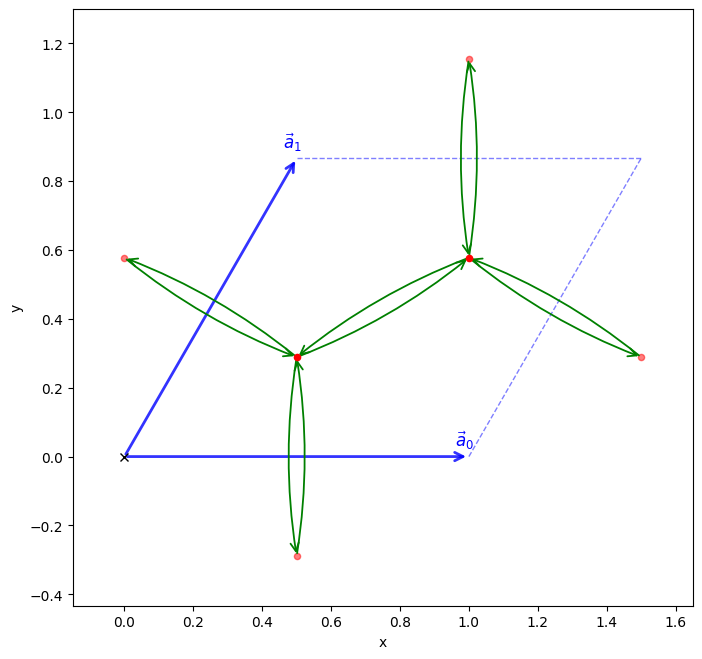

In [2]:
# define lattice vectors
lat_vecs = [[1, 0], [1/2, np.sqrt(3)/2]]
# define coordinates of orbitals
orb_vecs = [[1/3, 1/3], [2/3, 2/3]]

lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=[0, 1])

# make two dimensional tight-binding boron nitride model
my_model = TBModel(lat)

# set periodic model
delta = 0.4
t = -1.0
my_model.set_onsite([-delta, delta])
my_model.set_hop(t, 0, 1, [0, 0])
my_model.set_hop(t, 1, 0, [1, 0])
my_model.set_hop(t, 1, 0, [0, 1])
print(my_model)
my_model.visualize()

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 1
periodic directions         = [0]
number of orbitals          = 6
number of spin components   = 1
number of electronic states = 6

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283,  0.000]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
  # 2 ===> [ 1.000,  1.155]
  # 3 ===> [ 1.500,  1.443]
  # 4 ===> [ 1.500,  2.021]
  # 5 ===> [ 2.000,  2.309]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
  # 2 ===> [ 0.333,  1.333]
  # 3 ===> [ 0.667,  1.667]
  # 4 ===> [ 0.333,  2.333]
  # 5 ===> [ 0.667,  2.667]
No symmetry operations registered.

----

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

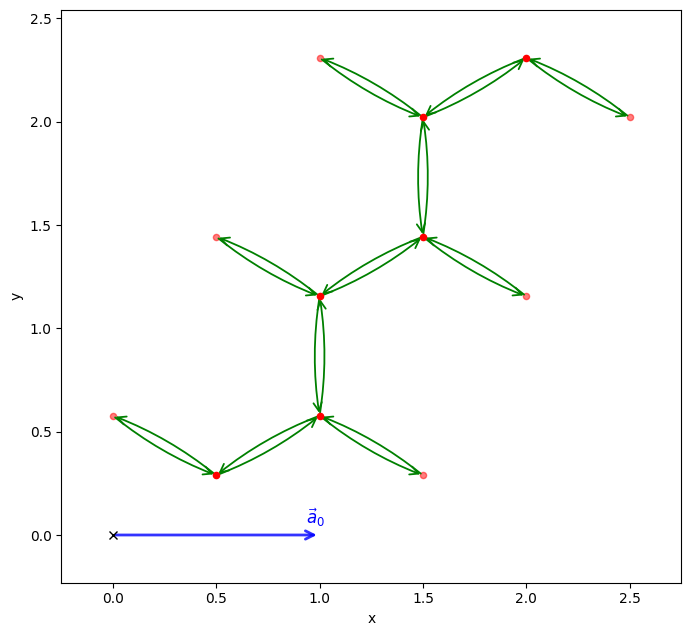

In [3]:
model_orig = my_model.cut_piece(3, 1, glue_edges=False)
print(model_orig)
model_orig.visualize()

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 1
periodic directions         = [0]
number of orbitals          = 6
number of spin components   = 1
number of electronic states = 6

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.000,  1.000]
Volume of unit cell (Cartesian) = 1.000 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283,  0.000]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 0.000,  0.577]
  # 2 ===> [ 0.000,  1.155]
  # 3 ===> [ 0.500,  1.443]
  # 4 ===> [ 0.500,  2.021]
  # 5 ===> [ 0.000,  2.309]
Orbital vectors (fractional):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 0.000,  0.577]
  # 2 ===> [ 0.000,  1.155]
  # 3 ===> [ 0.500,  1.443]
  # 4 ===> [ 0.500,  2.021]
  # 5 ===> [ 0.000,  2.309]
No symmetry operations registered.

----

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

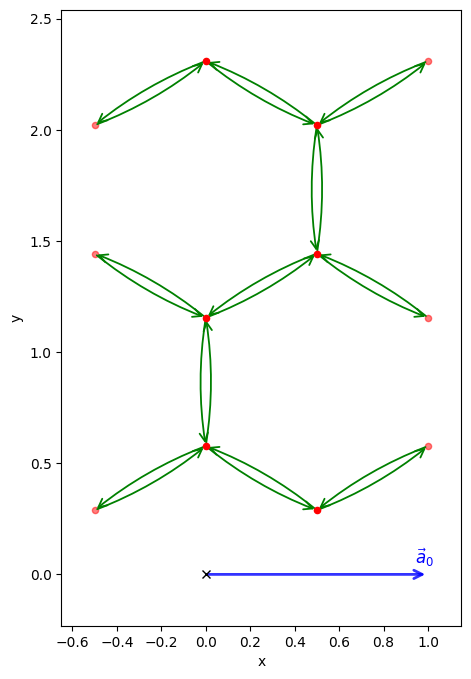

In [4]:
model_perp = model_orig.copy()
model_perp.change_nonperiodic_vector(1, to_home=True, to_home_warning=False)
print(model_perp)
model_perp.visualize()

Applying phase to state at beginning to end of open periodic axis.
Appending state at beginning to end of open periodic axis.


Berry Phase Original model = -0.4425504
Applying phase to state at beginning to end of open periodic axis.
Appending state at beginning to end of open periodic axis.
Berry Phase Revised model = -0.0000000


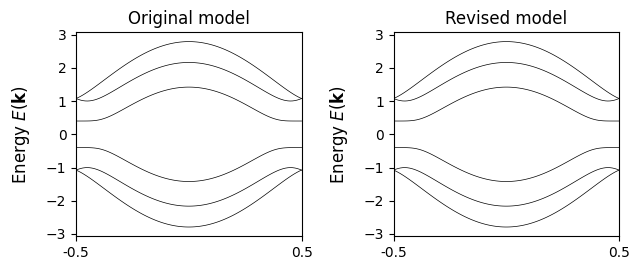

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(6.5, 2.8))

def run_model(model, panel, title):
    k_nodes = [[-0.5], [0.5]]

    model.plot_bands(k_path=k_nodes, nk=100, fig=fig, ax=ax[panel], lc="k", lw=0.5)
    ax[panel].set_title(title)
    ax[panel].set_xticklabels([-0.5, 0.5])

    mesh = Mesh(dim_k=model.dim_k, axis_types=["k"])
    mesh.build_grid(shape=(40,), gamma_centered=True)
    wf = WFArray(model, mesh)
    wf.solve_mesh()

    n_occ = model.nstate // 2
    berry_phase = wf.berry_phase(0, range(n_occ))
    print(f"Berry Phase {title} = {berry_phase:.7f}")

run_model(model_orig, 0, "Original model")
run_model(model_perp, 1, "Revised model")

fig.tight_layout()
plt.show()